<a href="https://colab.research.google.com/github/Dungmeww/eye_diseases_classification/blob/main/deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

!pip install seaborn -q

Mounted at /content/drive
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

# ── Chỉnh đúng tên thư mục trong Drive ──
DATA_DIR    = "/content/drive/MyDrive/archive"
CLASS_NAMES = ["normal", "cataract", "glaucoma", "diabetic_retinopathy"]
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
SEED          = 42
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 30
LR_PHASE1     = 1e-3
LR_PHASE2     = 1e-5

# Thư mục lưu kết quả (tự động tạo)
OUTPUT_DIR = "/content/drive/MyDrive/eye_disease_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config OK!")

Config OK!


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# ── Thu thập đường dẫn ảnh ──
def collect_paths(data_dir):
    paths, labels = [], []
    for idx, class_name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            print(f"[WARN] Không thấy thư mục: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(class_dir, fname))
                labels.append(idx)
    print(f"\n Tổng ảnh: {len(paths)}")
    for i, c in enumerate(CLASS_NAMES):
        print(f"   {c}: {labels.count(i)} ảnh")
    return paths, labels

# ── Chia train/val/test ──
def split_data(paths, labels):
    x_train, x_temp, y_train, y_temp = train_test_split(
        paths, labels, test_size=0.30,
        random_state=SEED, stratify=labels
    )
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=0.50,
        random_state=SEED, stratify=y_temp
    )
    print(f"\nTrain: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")
    return (x_train, y_train), (x_val, y_val), (x_test, y_test)

# ── Tiền xử lý ảnh ──
def preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    # ResNet50 cần preprocess riêng
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, label

# ── Augmentation ──
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label

# ── Build tf.data.Dataset ──
def build_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.int32))
    )
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(len(paths), seed=SEED)
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ── Chạy ──
paths, labels = collect_paths(DATA_DIR)
(x_tr, y_tr), (x_val, y_val), (x_te, y_te) = split_data(paths, labels)

train_ds = build_dataset(x_tr, y_tr, training=True)
val_ds   = build_dataset(x_val, y_val)
test_ds  = build_dataset(x_te, y_te)
print("Dataset OK!")


✅ Tổng ảnh: 4229
   normal: 1074 ảnh
   cataract: 1038 ảnh
   glaucoma: 1019 ảnh
   diabetic_retinopathy: 1098 ảnh

Train: 2960 | Val: 634 | Test: 635
Dataset OK!


In [ ]:
from tensorflow.keras import layers, models

def build_resnet50_model():
    # ── Load ResNet50 pretrained ImageNet, bỏ lớp top ──
    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(*  IMG_SIZE, 3)
    )

    # ── Phase 1: Freeze toàn bộ base model ──
    base_model.trainable  = False
    print(f"Base model layers: {len(base_model.layers)}")
    print(f"Trainable layers:  {len(base_model.trainable_variables)}")

    # ── Xây dựng model hoàn chỉnh ──
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="ResNet50_Transfer")
    return model, base_model

model, base_model = build_resnet50_model()
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers: 175
Trainable layers:  0


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,668 (92.11 MB)

 Trainable params: 557,956 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
import matplotlib.pyplot as plt

# ── Compile Phase 1 ──
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_PHASE1),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_p1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        f"{OUTPUT_DIR}/resnet50_phase1.keras",
        monitor="val_accuracy", save_best_only=True
    )
]

print("="*50)
print("PHASE 1: Training classifier (base frozen)")
print("="*50)

history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_p1
)

print(f"\n Phase 1 xong! Val Accuracy: {max(history1.history['val_accuracy']):.4f}")

PHASE 1: Training classifier (base frozen)
Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.6767 - loss: 0.8190 - val_accuracy: 0.8170 - val_loss: 0.5256
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 93s 153ms/step - accuracy: 0.7743 - loss: 0.5624 - val_accuracy: 0.8565 - val_loss: 0.4157
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 39s 142ms/step - accuracy: 0.8098 - loss: 0.4901 - val_accuracy: 0.8407 - val_loss: 0.3962
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 46s 213ms/step - accuracy: 0.8182 - loss: 0.4681 - val_accuracy: 0.8691 - val_loss: 0.3597
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 79s 176ms/step - accuracy: 0.8274 - loss: 0.4352 - val_accuracy: 0.8849 - val_loss: 0.3209
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 42s 166ms/step - accuracy: 0.8416 - loss: 0.4023 - val_accuracy: 0.8722 - val_loss: 0.3397
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 37s 139ms/step - accuracy: 0.8530 - loss: 0.3852 - val_accuracy: 0.8707 - val_loss: 0.3277
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 42s 156ms/step - a

In [ ]:
# ── Unfreeze 50 lớp cuối của ResNet50 ──
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 50

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers sau unfreeze: {trainable_count}/{len(base_model.layers)}")

# ── Compile lại với LR nhỏ hơn ──
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_PHASE2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        f"{OUTPUT_DIR}/resnet50_phase2_best.keras",
        monitor="val_accuracy", save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    )
]

print("="*50)
print("PHASE 2: Fine-tuning (50 lớp cuối unfreeze)")
print("="*50)

history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_p2
)

Trainable layers sau unfreeze: 50/175
PHASE 2: Fine-tuning (50 lớp cuối unfreeze)
Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 95s 429ms/step - accuracy: 0.7142 - loss: 1.3685 - val_accuracy: 0.8486 - val_loss: 0.4430 - learning_rate: 1.0000e-05
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 52s 278ms/step - accuracy: 0.8402 - loss: 0.4702 - val_accuracy: 0.8912 - val_loss: 0.2775 - learning_rate: 1.0000e-05
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 56s 281ms/step - accuracy: 0.8743 - loss: 0.3667 - val_accuracy: 0.9085 - val_loss: 0.2343 - learning_rate: 1.0000e-05
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 51s 202ms/step - accuracy: 0.8878 - loss: 0.3036 - val_accuracy: 0.9085 - val_loss: 0.2324 - learning_rate: 1.0000e-05
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 45s 222ms/step - accuracy: 0.8959 - loss: 0.2841 - val_accuracy: 0.9148 - val_loss: 0.2231 - learning_rate: 1.0000e-05
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 82s 221ms/step - accuracy: 0.9115 - loss: 0.2459 - val_accuracy: 0.9196 - val_loss: 0.2202 - le

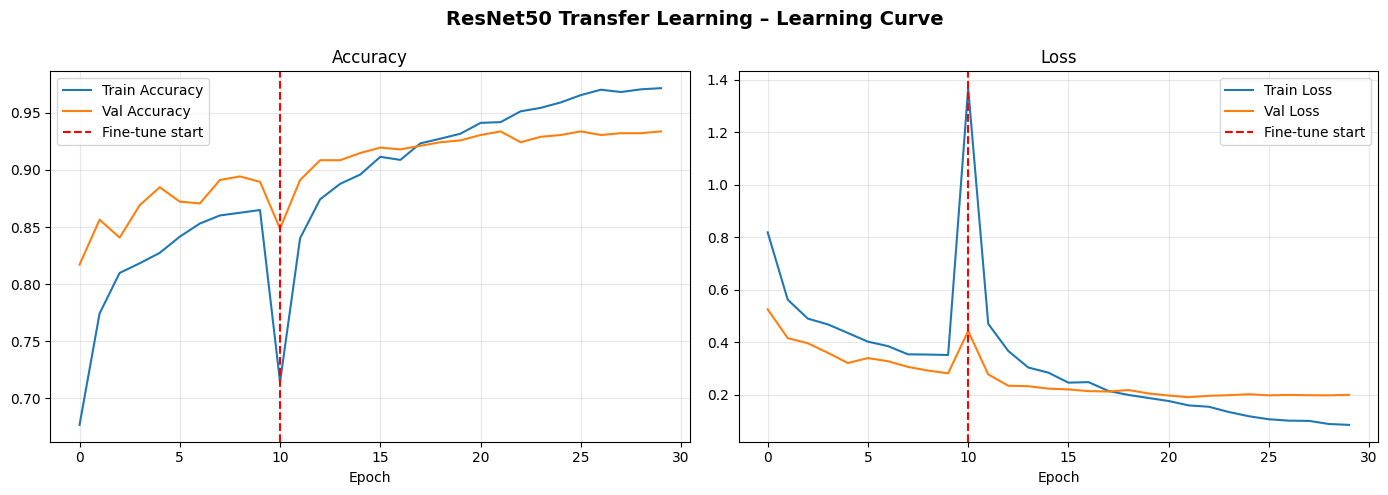

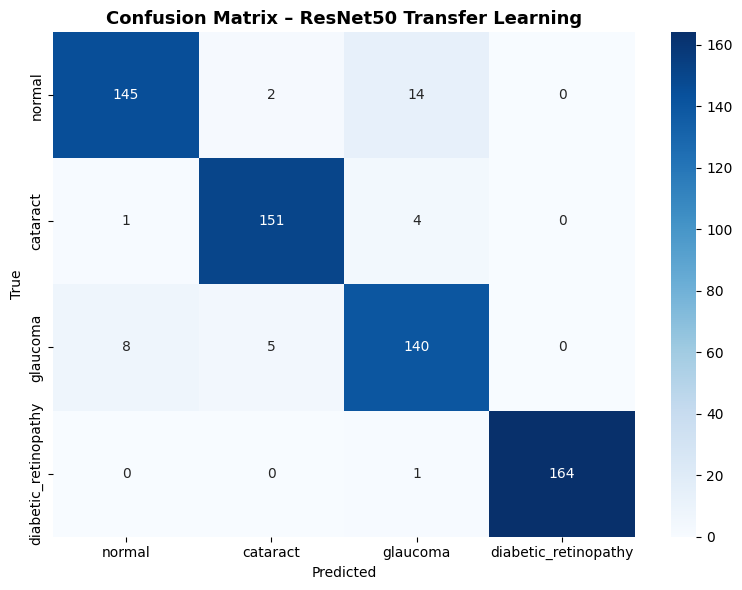


📋 Classification Report:
                      precision    recall  f1-score   support

              normal     0.9416    0.9006    0.9206       161
            cataract     0.9557    0.9679    0.9618       156
            glaucoma     0.8805    0.9150    0.8974       153
diabetic_retinopathy     1.0000    0.9939    0.9970       165

            accuracy                         0.9449       635
           macro avg     0.9444    0.9444    0.9442       635
        weighted avg     0.9455    0.9449    0.9450       635


🏆 Test Accuracy: 94.49%


In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ── Ghép history 2 phase ──
def plot_combined_history(h1, h2, save_path):
    acc  = h1.history["accuracy"]      + h2.history["accuracy"]
    val  = h1.history["val_accuracy"]  + h2.history["val_accuracy"]
    loss = h1.history["loss"]          + h2.history["loss"]
    vloss= h1.history["val_loss"]      + h2.history["val_loss"]
    ep1  = len(h1.history["accuracy"])  # điểm chuyển phase

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("ResNet50 Transfer Learning – Learning Curve", fontsize=14, fontweight="bold")

    for ax, train_data, val_data, title in zip(
        axes,
        [acc, loss], [val, vloss],
        ["Accuracy", "Loss"]
    ):
        ax.plot(train_data, label=f"Train {title}")
        ax.plot(val_data,   label=f"Val {title}")
        ax.axvline(ep1, color="red", linestyle="--", label="Fine-tune start")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_combined_history(history1, history2,
                      f"{OUTPUT_DIR}/resnet50_learning_curve.png")

# ── Confusion Matrix ──
y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
cm = confusion_matrix(y_te, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Confusion Matrix – ResNet50 Transfer Learning",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/resnet50_confusion_matrix.png", dpi=150)
plt.show()

# ── Classification Report ──
print("\n Classification Report:")
print(classification_report(y_te, y_pred, target_names=CLASS_NAMES, digits=4))

acc_final = np.mean(y_pred == y_te)
print(f"\n Test Accuracy: {acc_final*100:.2f}%")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. Gỡ cài đặt phiên bản jax hiện tại đang lỗi
!pip uninstall jax jaxlib -y

# 2. Cài đặt lại phiên bản jax và jaxlib ổn định, tương thích hoàn hảo với TensorFlow trên Colab
!pip install jax==0.4.26 jaxlib==0.4.26

# 3. Ép cài đặt phiên bản Gradio ổn định tránh xung đột ngầm
!pip install gradio -q

Found existing installation: jax 0.4.26
Uninstalling jax-0.4.26:
  Successfully uninstalled jax-0.4.26
Found existing installation: jaxlib 0.4.26
Uninstalling jaxlib-0.4.26:
  Successfully uninstalled jaxlib-0.4.26
  Using cached jax-0.4.26-py3-none-any.whl.metadata (23 kB)
  Using cached jaxlib-0.4.26-cp312-cp312-manylinux2014_x86_64.whl.metadata (1.8 kB)
Using cached jax-0.4.26-py3-none-any.whl (1.9 MB)
Using cached jaxlib-0.4.26-cp312-cp312-manylinux2014_x86_64.whl (78.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jax]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orbax-checkpoint 0.12.0 requires jax>=0.6.0, but you have jax 0.4.26 which is incompatible.
flax 0.11.2 requires jax>=0.6.0, but you have jax 0.4.26 which is incompatible.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0.4.26 which is incompatible.
optax 0.2.8 requires jaxlib>=0.5.3, 

In [ ]:
import numpy as np
import tensorflow as tf
import gradio as gr
from PIL import Image

# 1. Tải mô hình và cấu hình nhãn
MODEL_PATH = "/content/drive/MyDrive/eye_disease_outputs/resnet50_phase2_best.keras"
model = tf.keras.models.load_model(MODEL_PATH)
CLASS_NAMES_VI = ["Bình thường", "Đục thủy tinh thể", "Tăng nhãn áp", "Võng mạc tiểu đường"]

def predict_eye_disease(input_image):
    if input_image is None: return "Vui lòng tải ảnh lên!", None

    # Tự động Crop bỏ viền đen
    img_array = np.array(input_image)
    gray = np.mean(img_array, axis=2)
    rows, cols = np.any(gray > 30, axis=1), np.any(gray > 30, axis=0)
    if np.any(rows) and np.any(cols):
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]
        input_image = Image.fromarray(img_array[rmin:rmax, cmin:cmax])

    # Tiền xử lý ảnh cho ResNet50
    img = input_image.resize((224, 224))
    x = tf.keras.utils.img_to_array(img)
    x = tf.keras.applications.resnet50.preprocess_input(x)
    x = np.expand_dims(x, axis=0)

    # Dự đoán
    preds = model.predict(x, verbose=0)[0]
    idx = np.argmax(preds)

    # Trả kết quả dạng chữ và biểu đồ phần trăm
    res_text = f"## 🩺 Chẩn đoán: {CLASS_NAMES_VI[idx]} ({preds[idx]*100:.2f}%)"
    res_chart = {CLASS_NAMES_VI[i]: float(preds[i]) for i in range(4)}
    return res_text, res_chart

demo = gr.Interface(
    fn=predict_eye_disease,
    inputs=gr.Image(type="pil", sources=["upload"], label="Tải ảnh đáy mắt từ máy tính"),
    outputs=[gr.Markdown(label="Kết luận"), gr.Label(num_top_classes=4, label="Xác suất (%)")],
    title="👁️ Hệ Thống Chẩn Đoán Bệnh Lý Đáy Mắt",
    description="Vui lòng chọn file ảnh chụp đáy mắt để hệ thống phân tích.",
    submit_btn="🔍 Bắt đầu phân tích",
    flagging_mode="never"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://11c08ea278244f1e4b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
